# General

In [1]:
import h5py
import numpy as np
from h5py import Reference
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

class Struct:
    def __init__(self, fields):
        for k, v in fields.items():
            setattr(self, k, v)

    def __repr__(self):
        keys = ", ".join(sorted(self.__dict__.keys()))
        return f"Struct({keys})"


def _from_compound(f, rec):
    """
    Convert a numpy.void (compound record) into a Struct,
    recursively converting nested compounds and references.
    """
    out = {}
    for name in rec.dtype.names:
        field = rec[name]

        # Follow HDF5 references
        if isinstance(field, Reference):
            target = f[field]
            out[name] = _load_node(f, target)

        # Nested compound
        elif isinstance(field, np.void) and field.dtype.names is not None:
            out[name] = _from_compound(f, field)

        # Scalar array -> scalar
        elif isinstance(field, np.ndarray) and field.shape == ():
            out[name] = field.item()

        else:
            out[name] = field

    return Struct(out)


def _load_node(f, node):
    """
    Recursively load any HDF5 node (group or dataset) into Python objects.
    Groups / compound datasets become Structs.
    """
    # Group: recurse on children
    if isinstance(node, h5py.Group):
        fields = {name: _load_node(f, node[name]) for name in node.keys()}
        return Struct(fields)

    # Dataset
    if isinstance(node, h5py.Dataset):
        data = node[()]

        # Scalar compound record
        if isinstance(data, np.void) and data.dtype.names is not None:
            return _from_compound(f, data)

        # 1D array of length 1 containing a compound record
        if (isinstance(data, np.ndarray) and data.dtype.names is not None
                and data.shape == (1,)):
            return _from_compound(f, data[0])

        # Scalar numeric
        if isinstance(data, np.ndarray) and data.shape == ():
            return data.item()

        # Regular array
        return data

    # Fallback
    return node


def load_res(path):

    with h5py.File(path, "r") as f:
        # Try common root names
        if "res_x" in f:
            root = f["res_x"]
        elif "res" in f:
            root = f["res"]
        else:
            # fall back to first key
            root = f[list(f.keys())[0]]

        return _load_node(f, root)

# Data

In [2]:
L_list = [8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52] 

for L in L_list:
    fname = f"Data/2d-L{L}-x.jld2"
    res = load_res(fname)

    # ======================================================
    # 1) SAMPLE-CONNECTED 
    # ======================================================
    sc_root = res.sample_connected
    sc = sc_root.product if hasattr(sc_root, "product") else sc_root


    globals()[f"C_SC_osc_stag_{L}"]      = sc.osc.stag.mean
    globals()[f"C_SC_osc_stag_err_{L}"]  = sc.osc.stag.err
    globals()[f"C_SC_osc_stag_std_{L}"]  = sc.osc.stag.std
    globals()[f"C_SC_osc_stag_var_{L}"]  = sc.osc.stag.var

    # ======================================================
    # 2) FIRST-MOMENT
    # ======================================================
    dc_root = res.disorder_connected
    dc_prod = dc_root.product if hasattr(dc_root, "product") else dc_root
    dc_fix  = dc_root.fix    if hasattr(dc_root, "fix")    else None

    globals()[f"C_DC_prod_osc_stag_{L}"]      = dc_prod.osc.stag.mean
    globals()[f"C_DC_prod_osc_stag_err_{L}"]  = dc_prod.osc.stag.err
    globals()[f"C_DC_prod_osc_stag_std_{L}"]  = dc_prod.osc.stag.std
    globals()[f"C_DC_prod_osc_stag_var_{L}"]  = dc_prod.osc.stag.var

    # ======================================================
    # GAMMA–GAMMA TWO-POINT CORRELATORS
    # ======================================================
    gg = res.gamma2pt
    ns = 200 * L
    nsqrt = np.sqrt(ns)

    # ---- Cx ----
    globals()[f"G2_Cx_{L}"]      = gg.Cx.mean
    globals()[f"G2_Cx_std_{L}"]  = gg.Cx.std
    globals()[f"G2_Cx_var_{L}"]  = gg.Cx.var
    globals()[f"G2_Cx_err_{L}"]  = gg.Cx.std / nsqrt

    # ---- Cx_abs ----
    globals()[f"G2_Cx_abs_{L}"]      = gg.Cx_abs.mean
    globals()[f"G2_Cx_abs_std_{L}"]  = gg.Cx_abs.std
    globals()[f"G2_Cx_abs_var_{L}"]  = gg.Cx_abs.var
    globals()[f"G2_Cx_abs_err_{L}"]  = gg.Cx_abs.std / nsqrt

# Fig.1(b) - Manuscript

Saved high-quality PDF as: Figs/2d-majorana-EA-FM.pdf


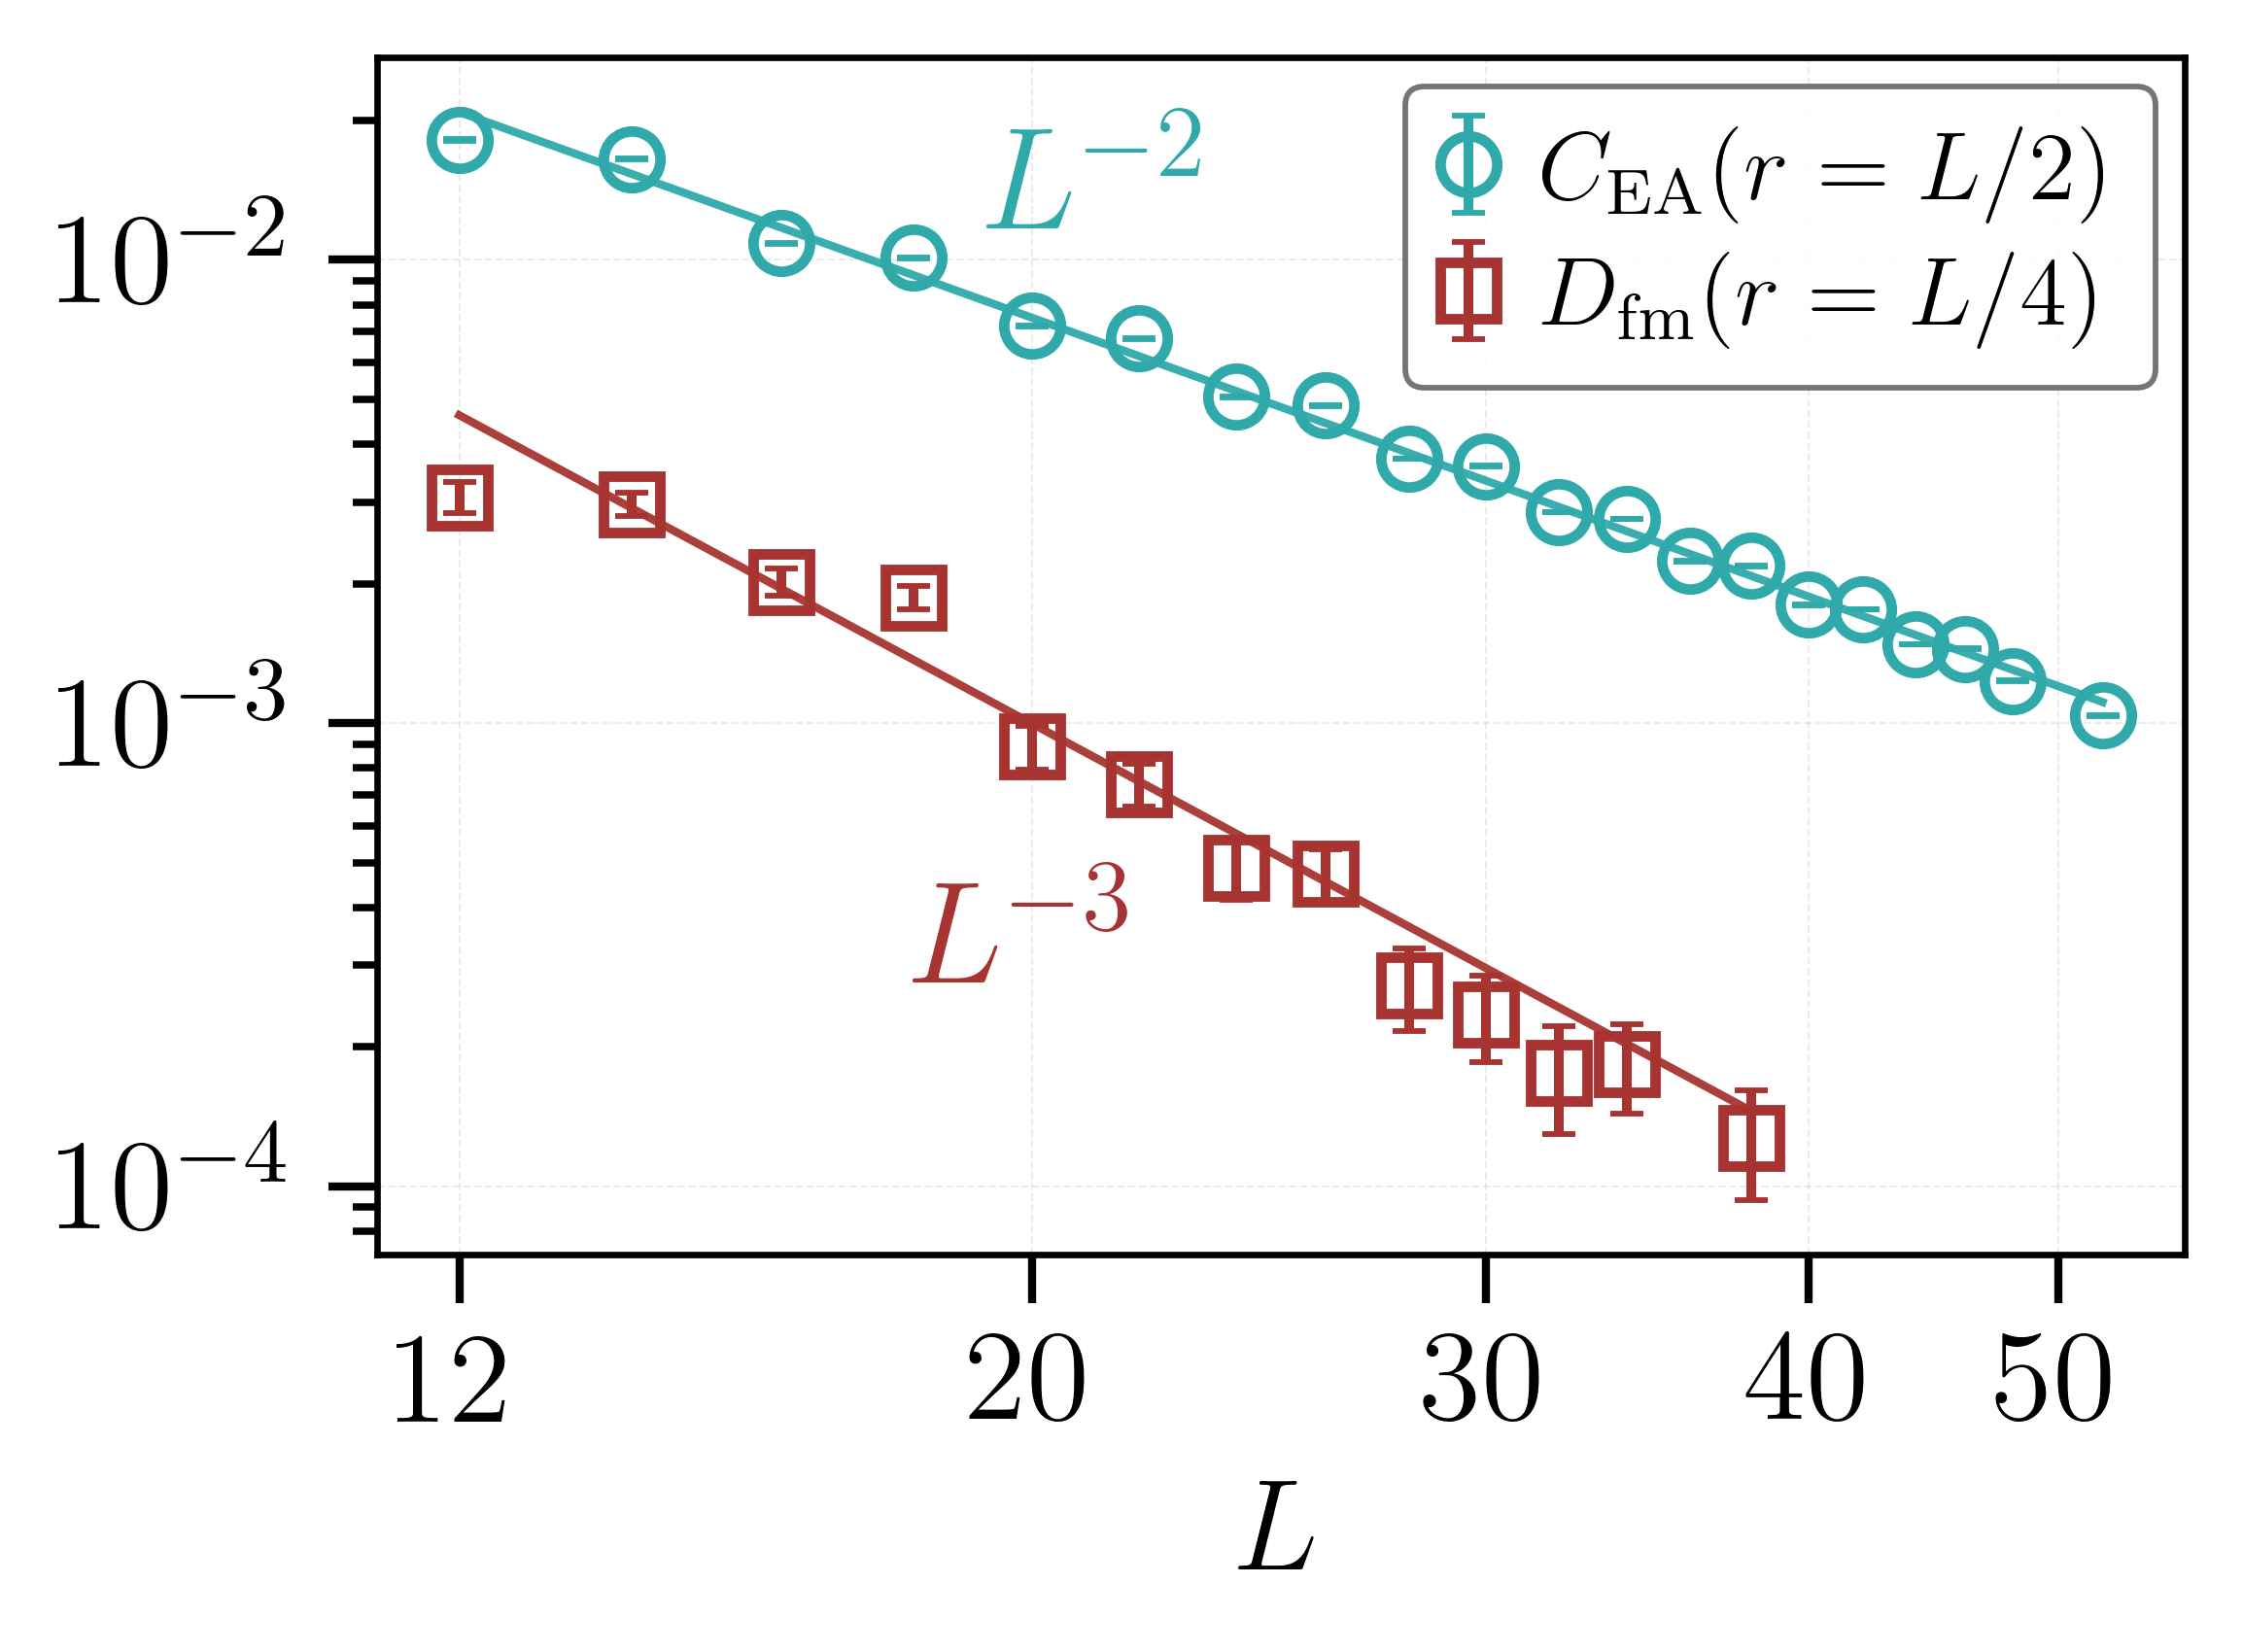

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, NullLocator
import matplotlib as mpl

# ---------------------------------------------------------
# Matplotlib / LaTeX settings  
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ANNOT_FSIZE  = 18

# ---------------------------------------------------------
# Parameters 
# ---------------------------------------------------------
SNR_MIN_CE   = 3
SNR_MIN_CA   = 3
R_MIN_CE     = 3
R_MIN_CA     = 3

# System sizes 
L_list = [12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52]
L_ticks = [12, 20, 30, 40, 50]

# ---------------------------------------------------------
# Colors 
# ---------------------------------------------------------
ce_color = '#2fa9aaff'   # EA
ca_color = '#a73431ff'   # FM

def fit_A_fixed_m(L, y, m_fixed, yerr=None):
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        raise ValueError("All y must be positive to fit in log-space.")

    logA_samples = np.log(y) - m_fixed * np.log(L)

    if yerr is None:
        logA = np.mean(logA_samples)
    else:
        yerr = np.asarray(yerr, dtype=float)
        snr = y / yerr
        w = snr**2
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        logA = np.sum(w * logA_samples) / np.sum(w) if np.sum(w) > 0 else np.mean(logA_samples)

    return float(np.exp(logA))

def place_scaling_label_near_line(ax, A, m_fixed, Lmin, Lmax, frac, y_mult, color,
                                 text=r'$L^{-2}$', fontsize=ANNOT_FSIZE,
                                 ha='left', va='center'):
    L0 = float(np.exp(np.log(Lmin) + frac * (np.log(Lmax) - np.log(Lmin))))
    y0 = float(A * L0**(m_fixed))

    ax.text(
        L0, y0 * y_mult,
        text,
        fontsize=fontsize,
        color=color,
        ha=ha, va=va,
        zorder=6
    )

# ---------------------------------------------------------
# Figure / axes  
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

ce_line_info = None
fm_line_info = None

# ======================================================
# 0) GLOBAL POSITIVITY PASS 
# ======================================================
for L in L_list:
    # EA
    y = np.asarray(globals()[f"G2_Cx_abs_{L}"], dtype=float)
    e = np.asarray(globals()[f"G2_Cx_abs_err_{L}"], dtype=float)
    keep = np.isfinite(y) & np.isfinite(e) & (y > 0) & (e > 0)
    y2, e2 = y.copy(), e.copy()
    y2[~keep] = np.nan
    e2[~keep] = np.nan
    globals()[f"G2_Cx_abs_{L}"] = y2
    globals()[f"G2_Cx_abs_err_{L}"] = e2

    # FM
    y = np.asarray(globals()[f"C_DC_prod_osc_stag_{L}"], dtype=float)
    e = np.asarray(globals()[f"C_DC_prod_osc_stag_err_{L}"], dtype=float)
    keep = np.isfinite(y) & np.isfinite(e) & (y > 0) & (e > 0)
    y2, e2 = y.copy(), e.copy()
    y2[~keep] = np.nan
    e2[~keep] = np.nan
    globals()[f"C_DC_prod_osc_stag_{L}"] = y2
    globals()[f"C_DC_prod_osc_stag_err_{L}"] = e2

# ======================================================
# 1) C_EA(r=cL), c = 0.50
# ======================================================
c_values_Ce = [0.50]
m_ce_fixed = -2.0

for c in c_values_Ce:
    Ls_used, vals, errs, rs_used = [], [], [], []

    for L in L_list:
        r_float = c * L
        r = int(np.round(r_float))
        if r % 2 == 0:
            r = r + 1 if (r_float >= r) else r - 1
        if r < R_MIN_CE:
            continue

        idx = r - 1
        y = globals()[f"G2_Cx_abs_{L}"][idx]
        e = globals()[f"G2_Cx_abs_err_{L}"][idx]
        if not np.isfinite(y) or not np.isfinite(e):
            continue

        Ls_used.append(L)
        vals.append(y)
        errs.append(e)
        rs_used.append(r)

    L_arr  = np.array(Ls_used)
    vals   = np.array(vals)
    errs   = np.array(errs)
    rs_arr = np.array(rs_used)

    snr = vals / errs
    mask = (snr >= SNR_MIN_CE) & (rs_arr >= R_MIN_CE)

    L_arr_f = L_arr[mask]
    vals_f  = vals[mask]
    errs_f  = errs[mask]

    eb = ax.errorbar(
        L_arr_f, vals_f, yerr=errs_f,
        fmt='o', color=ce_color,
        markersize=7, markerfacecolor='none',
        capsize=2, elinewidth=1.2, capthick=0.7,
        label=r'$C_{\text{EA}}(r=L/2)$',
        zorder=3
    )
    eb[0].set_markeredgecolor(ce_color)
    eb[0].set_markeredgewidth(1.3)

    A_ce = fit_A_fixed_m(L_arr_f, vals_f, m_fixed=m_ce_fixed, yerr=errs_f)
    L_fit = np.linspace(L_arr_f.min(), L_arr_f.max(), 300)
    ax.plot(L_fit, A_ce * L_fit**(m_ce_fixed),
            '-', lw=1.0, color=ce_color, alpha=0.95, zorder=2)

    ce_line_info = (A_ce, m_ce_fixed, L_fit.min(), L_fit.max())

# ======================================================
# 2) D_fm(r=cL), c = 0.25
# ======================================================
c_values_Ca = [0.25]
m_fm_fixed = -3.0

for c in c_values_Ca:
    Ls_used, vals, errs = [], [], []

    for L in L_list:
        r = int(np.floor(c * L))
        if r < R_MIN_CA:
            continue

        idx = r - 1
        y = globals()[f"C_DC_prod_osc_stag_{L}"][idx]
        e = globals()[f"C_DC_prod_osc_stag_err_{L}"][idx]
        if not np.isfinite(y) or not np.isfinite(e):
            continue

        Ls_used.append(L)
        vals.append(y)
        errs.append(e)

    L_arr = np.array(Ls_used)
    vals  = np.array(vals)
    errs  = np.array(errs)

    snr = vals / errs
    mask = (snr >= SNR_MIN_CA)

    L_arr_f = L_arr[mask]
    vals_f  = vals[mask]
    errs_f  = errs[mask]

    eb = ax.errorbar(
        L_arr_f, vals_f, yerr=errs_f,
        fmt='s', color=ca_color,
        markersize=7, markerfacecolor='none',
        capsize=2, elinewidth=1.2, capthick=0.7,
        label=r'${D}_{\text{fm}}(r=L/4)$',
        zorder=3
    )
    eb[0].set_markeredgecolor(ca_color)
    eb[0].set_markeredgewidth(1.3)

    A_fm = fit_A_fixed_m(L_arr_f, vals_f, m_fixed=m_fm_fixed, yerr=errs_f)
    L_fit = np.linspace(L_arr_f.min(), L_arr_f.max(), 300)
    ax.plot(L_fit, A_fm * L_fit**(m_fm_fixed),
            '-', lw=1.0, color=ca_color, alpha=0.95, zorder=2)

    fm_line_info = (A_fm, m_fm_fixed, L_fit.min(), L_fit.max())

# ---------------------------------------------------------
# Annotations 
# ---------------------------------------------------------
if ce_line_info is not None:
    A_ce, m_ce, Lmin, Lmax = ce_line_info
    place_scaling_label_near_line(ax, A_ce, m_ce, Lmin, Lmax,
                                 frac=0.32, y_mult=1.72,
                                 color=ce_color, text=r'$L^{-2}$')

if fm_line_info is not None:
    A_fm, m_fm, Lmin, Lmax = fm_line_info
    place_scaling_label_near_line(ax, A_fm, m_fm, Lmin, Lmax,
                                 frac=0.35, y_mult=0.24,
                                 color=ca_color, text=r'$L^{-3}$')

# ---------------------------------------------------------
# Axes + legend formatting 
# ---------------------------------------------------------
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
ax.set_ylabel('')

ax.set_xticks(L_ticks)
ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
ax.xaxis.set_minor_locator(NullLocator())

ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)


leg = ax.legend(
    fontsize=LEGEND_FONTSIZE,
    loc='upper right',
    handlelength=0.5,
    handletextpad=0.5,
    borderpad=0.4,
    labelspacing=0.3,
    borderaxespad=0.3,
    frameon=True,
)
frame = leg.get_frame()
frame.set_edgecolor('0.4')   # medium gray
frame.set_linewidth(0.7)
frame.set_facecolor('white')
frame.set_alpha(0.9)

# plt.tight_layout()

pdf_name = "Figs/2d-majorana-EA-FM.pdf"
plt.savefig(pdf_name, dpi=600, bbox_inches="tight", pad_inches=0.08)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()

# Fig.2 - Supplemental Material

## Fig.2(a)

Saved high-quality PDF as: Figs/various-r-L-2dMaj-EA.pdf


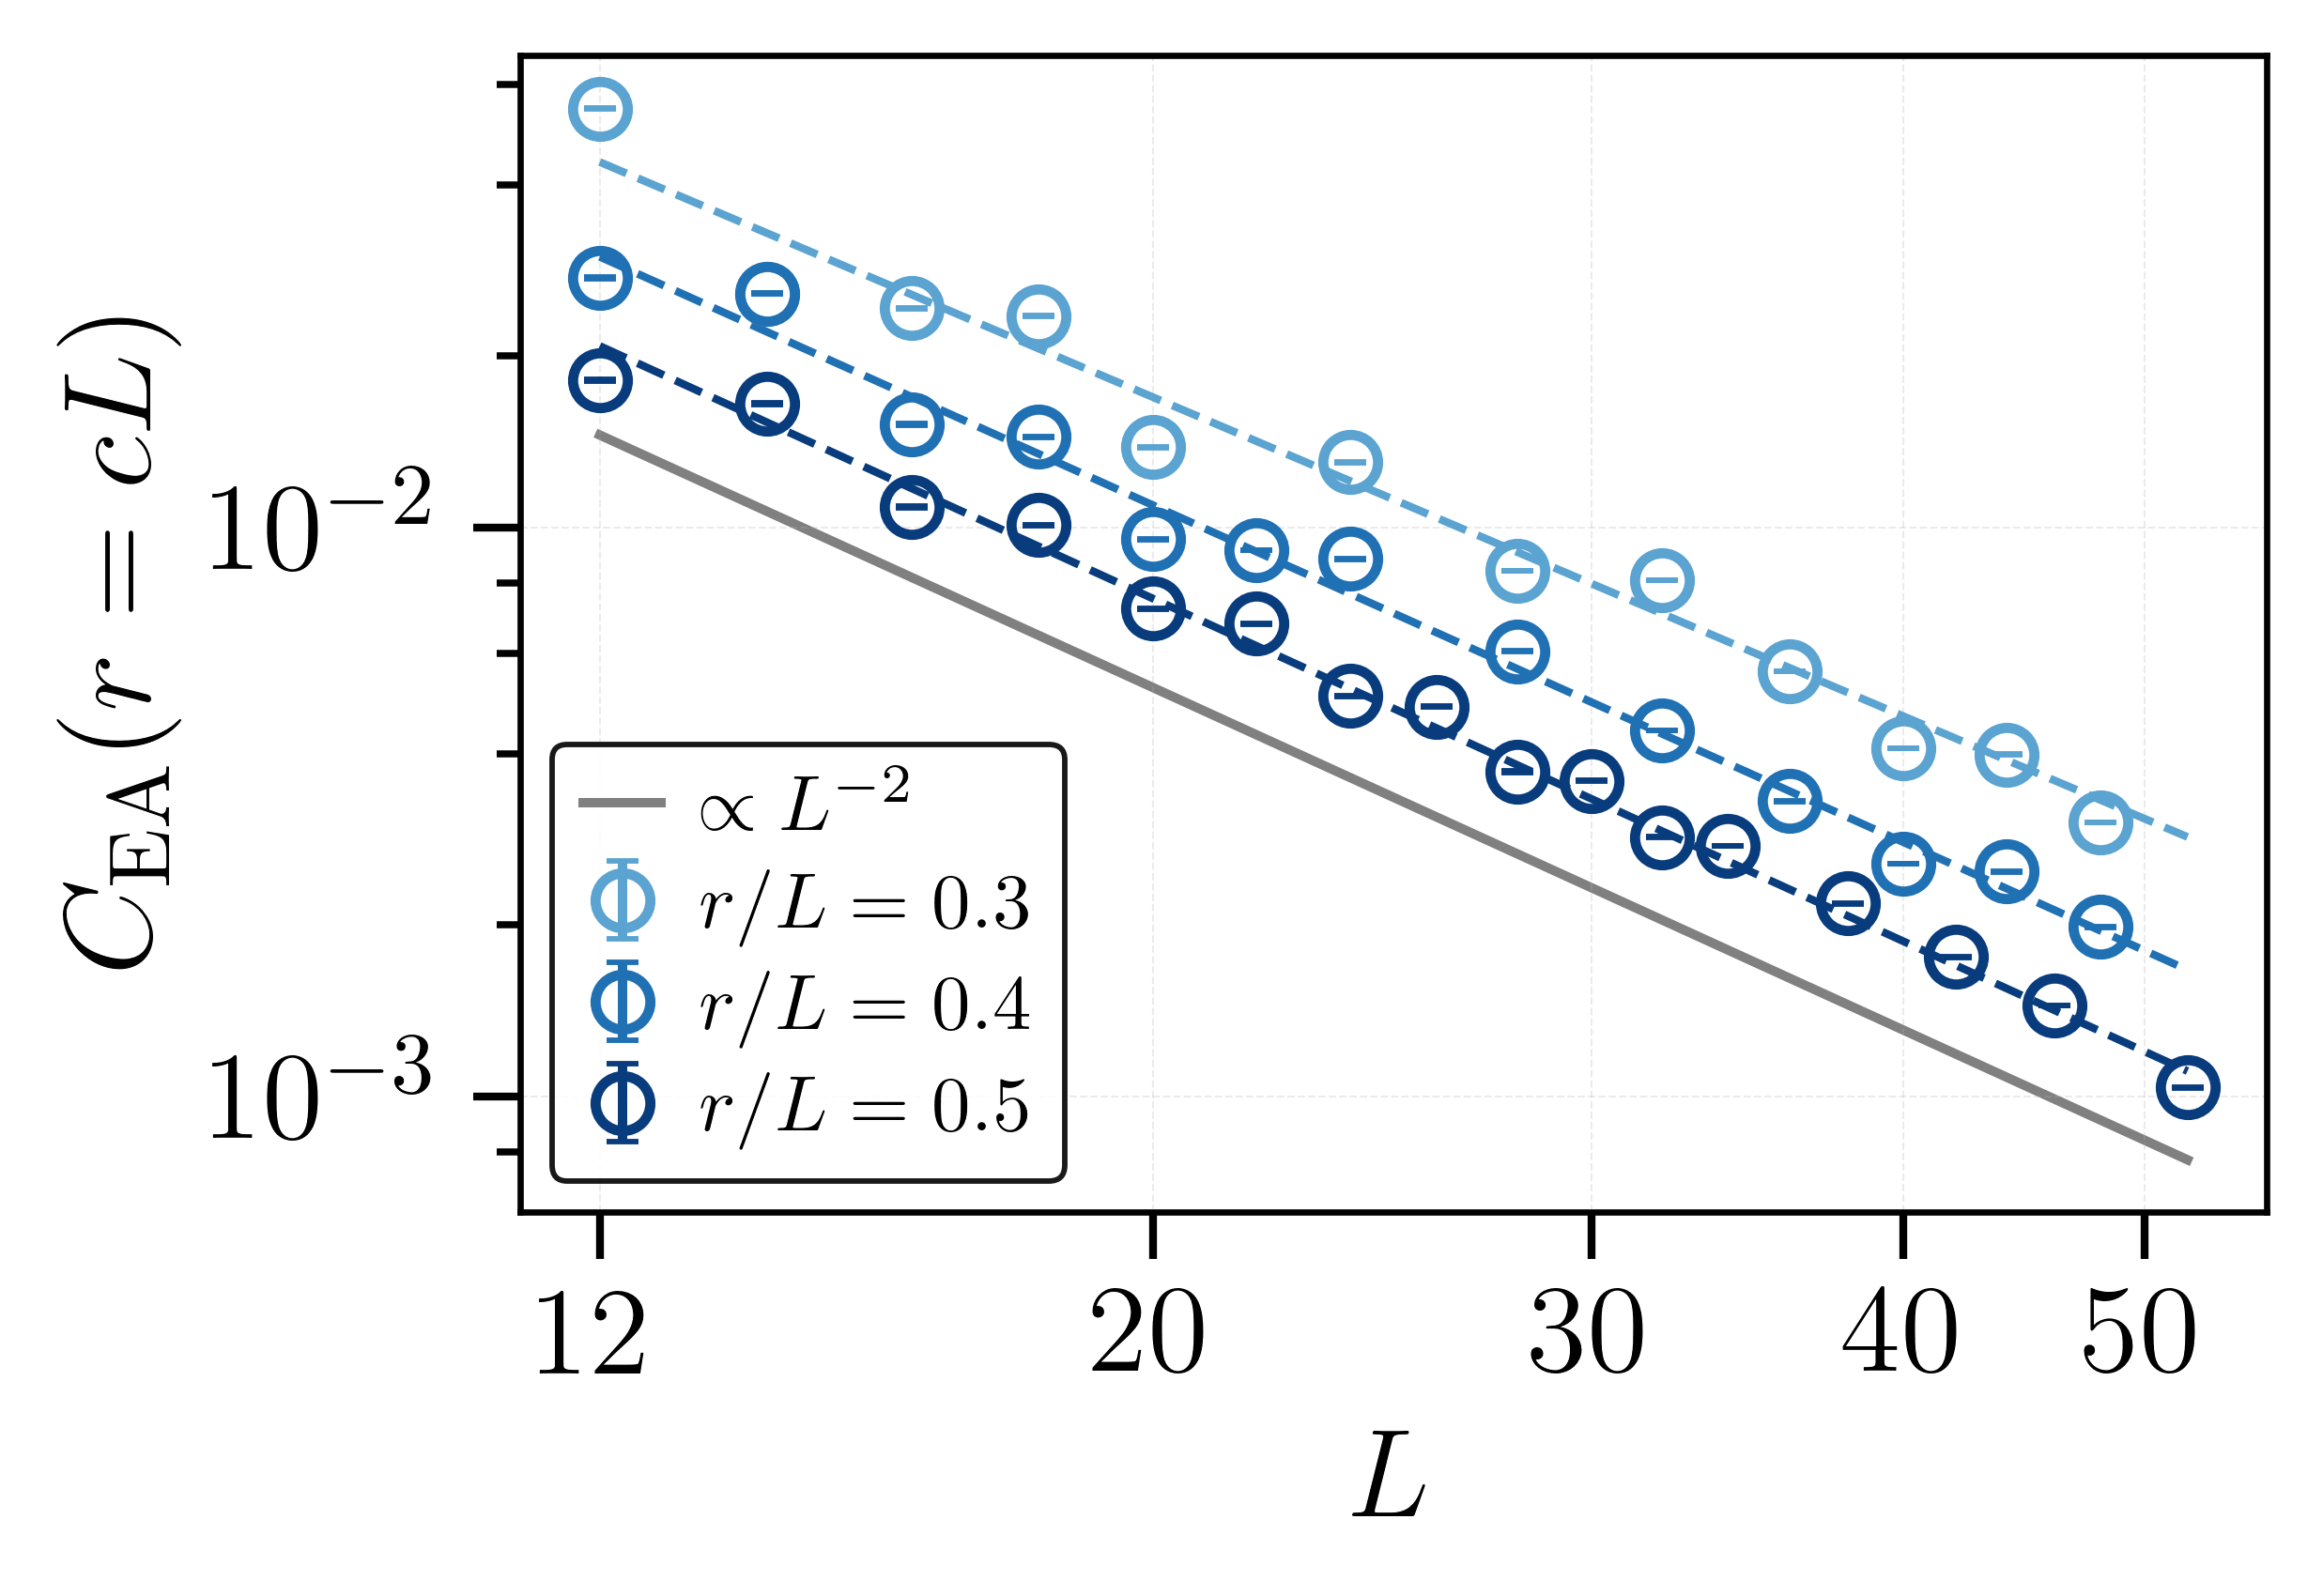

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (
    FormatStrFormatter, NullLocator,
    LogLocator, LogFormatterMathtext, NullFormatter, FixedLocator
)
import matplotlib as mpl
from matplotlib.cm import ScalarMappable

# ==========================================================
# User knobs (C_EA)
# ==========================================================
LEGEND_FONTSIZE = 10
SNR_MIN_CE = 2
R_MIN_CE   = 3

# -------------------- subsampling rules (PER-c, PLOT ONLY) --------------------
L_SAMPLE_RULES_BY_C = {
    0.30: [(18, 1), (52, 2)],
    0.40: [(22, 1), (52, 2)],
    0.50: [(32, 1), (52, 2)],
}
DEFAULT_L_SAMPLE_RULES = [(32, 1), (52, 2)]

def sample_by_L_rules(L, *arrays, rules):
    L = np.asarray(L, dtype=float)
    if L.size == 0:
        return (L,) + tuple(np.asarray(a) for a in arrays)

    order = np.argsort(L)
    Ls = L[order]
    arrs = [np.asarray(a)[order] for a in arrays]

    keep_global = np.zeros_like(Ls, dtype=bool)
    start = 0
    for Lmax, step in rules:
        end = np.searchsorted(Ls, Lmax, side='right')
        idx = np.arange(start, end)
        if idx.size > 0:
            keep_global[idx[::max(int(step), 1)]] = True
        start = end
        if start >= Ls.size:
            break

    Ls = Ls[keep_global]
    arrs = [a[keep_global] for a in arrs]
    return (Ls,) + tuple(arrs)

# ==========================================================
# Matplotlib / LaTeX settings 
# ==========================================================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 16
TICK_FSIZE   = 16
REF_LINE_COLOR = 'gray'

# -------------------- L list --------------------
L_list  = [12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52]
L_ticks = [12,20,30,40,50]

# -------------------- c values --------------------
c_values = [0.30, 0.4, 0.50]

def choose_odd_r_with_fallback(c, L, y_arr, e_arr, r_min, max_steps=3):
    r_float = float(c) * float(L)

    r0 = int(np.round(r_float))
    if r0 % 2 == 0:
        r0 = r0 + 1 if (r_float >= r0) else r0 - 1

    cand = [r0]
    for k in range(1, max_steps + 1):
        cand += [r0 - 2*k, r0 + 2*k]

    best = None
    best_dist = None

    n = min(len(y_arr), len(e_arr))

    for r in cand:
        if r < r_min:
            continue
        idx = r - 1
        if idx < 0 or idx >= n:
            continue

        yi = float(y_arr[idx])
        ei = float(e_arr[idx])

        if (not np.isfinite(yi)) or (not np.isfinite(ei)) or (yi <= 0.0) or (ei <= 0.0):
            continue

        dist = abs(r - r_float)
        if (best is None) or (dist < best_dist):
            best = (r, idx, yi, ei)
            best_dist = dist

    return best

# ======================
# Colormap control 
# ======================
CMAP_MIN = 0.55
CMAP_MAX = 0.95
cmap = plt.cm.Blues

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(values)
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * np.asarray(ts)
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

color_by_c = fixed_contrast_color_map(c_values)

# --- discrete colorbar  ---
c_sorted = sorted(c_values)
colors_sorted = [color_by_c[c] for c in c_sorted]
listed_cmap = mpl.colors.ListedColormap(colors_sorted)

if len(c_sorted) == 1:
    boundaries = np.array([c_sorted[0] - 0.5, c_sorted[0] + 0.5], dtype=float)
else:
    mids = [(c_sorted[i] + c_sorted[i+1]) / 2.0 for i in range(len(c_sorted) - 1)]
    first = c_sorted[0] - (mids[0] - c_sorted[0])
    last  = c_sorted[-1] + (c_sorted[-1] - mids[-1])
    boundaries = np.array([first] + mids + [last], dtype=float)

cbar_norm = mpl.colors.BoundaryNorm(boundaries, listed_cmap.N)

# =====================
# Figure
# =====================
fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

all_valid_L    = []
all_valid_vals = []

# ======================== main loop over c =========================
for c in c_values:

    Ls_used, vals, errs, rs_used = [], [], [], []

    for L in L_list:
        y_key = f"G2_Cx_abs_{L}"
        e_key = f"G2_Cx_abs_err_{L}"
        if (y_key not in globals()) or (e_key not in globals()):
            continue

        y_arr = np.asarray(globals()[y_key], dtype=float)
        e_arr = np.asarray(globals()[e_key], dtype=float)

        pick = choose_odd_r_with_fallback(c, L, y_arr, e_arr, r_min=R_MIN_CE, max_steps=3)
        if pick is None:
            continue

        r, idx, yi, ei = pick
        Ls_used.append(L)
        vals.append(yi)
        errs.append(ei)
        rs_used.append(r)

    if not vals:
        continue

    L_arr  = np.array(Ls_used, dtype=float)
    vals   = np.array(vals, dtype=float)
    errs   = np.array(errs, dtype=float)
    rs_arr = np.array(rs_used, dtype=float)

    snr = vals / errs
    mask = (snr >= SNR_MIN_CE) & (rs_arr >= R_MIN_CE)

    L_arr_f = L_arr[mask]
    vals_f  = vals[mask]
    errs_f  = errs[mask]

    all_valid_L.extend(L_arr_f.tolist())
    all_valid_vals.extend(vals_f.tolist())

    if len(vals_f) < 2:
        continue

    # -------------------- PER-c subsampling  --------------------
    rules_for_c = L_SAMPLE_RULES_BY_C.get(float(c), DEFAULT_L_SAMPLE_RULES)
    L_plot, vals_plot, errs_plot = sample_by_L_rules(L_arr_f, vals_f, errs_f, rules=rules_for_c)

    color = color_by_c[c]

    eb = ax.errorbar(
        L_plot, vals_plot,
        yerr=errs_plot,
        fmt='o',
        markersize=7,
        markerfacecolor='none',
        capsize=2,
        elinewidth=1.2,
        capthick=0.7,
        color=color,
        label=rf'$r/L={c}$',
        zorder=3
    )
    eb[0].set_markeredgecolor(color)
    eb[0].set_markeredgewidth(1.3)

    # -------- power-law fit --------
    xlog = np.log(L_arr_f)
    ylog = np.log(vals_f)
    m, b_lin = np.polyfit(xlog, ylog, 1)
    A = np.exp(b_lin)

    L_fit = np.linspace(min(L_arr_f), max(L_arr_f), 200)
    ax.plot(L_fit, A * L_fit**m, '--', lw=1, color=color, alpha=1, zorder=2)

# -------------------- L^{-2} reference line  --------------------
if len(all_valid_L) > 0:
    L_arr_all = np.array(all_valid_L, dtype=float)
    vals_all  = np.array(all_valid_vals, dtype=float)

    Lmin_valid = L_arr_all.min()
    Lmax_valid = L_arr_all.max()

 
    A_ref = np.min(vals_all * (L_arr_all**2)) * 0.8

    L_ref = np.linspace(Lmin_valid, Lmax_valid, 200)
    y_ref = A_ref * L_ref**(-2)

    ax.plot(
        L_ref, y_ref,
        color=REF_LINE_COLOR, lw=1.2, ls='-',
        label=r'$\propto L^{-2}$',
        zorder=1
    )

# -------------------- axes formatting --------------------
ax.set_xscale('log')
ax.set_yscale('log')

major_yticks = [1e-2, 1e-3, 1e-5, 1e-7]
ax.yaxis.set_major_locator(FixedLocator(major_yticks))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))

ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=100))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis='y', which='minor', left=True, right=False)

ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
ax.set_ylabel(r'$C_{\mathrm{EA}}(r=cL)$', fontsize=LABEL_FSIZE)

ax.set_xticks(L_ticks)
ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
ax.xaxis.set_minor_locator(NullLocator())

ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

leg = ax.legend(
    fontsize=LEGEND_FONTSIZE,
    loc='lower left',
    handlelength=1,
    handletextpad=0.5,
    borderpad=0.4,
    labelspacing=0.3,
    borderaxespad=0.4,
    frameon=True
)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(0.7)
frame.set_facecolor('white')
frame.set_alpha(0.9)

# -------------------- colorbar for r/L --------------------
sm = ScalarMappable(norm=cbar_norm, cmap=listed_cmap)
sm.set_array([])

pdf_name = "Figs/various-r-L-2dMaj-EA.pdf"

plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,              
    bbox_inches="tight",   
    pad_inches=0.08,      
    transparent=False      
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()

## Fig.2(b)

c = 0.25: exponent m = -3.1066, R^2 = 0.9725, N = 13
c = 0.30: exponent m = -3.0445, R^2 = 0.9389, N = 9
c = 0.35: exponent m = -3.1164, R^2 = 0.9448, N = 6
c = 0.40: exponent m = -3.0111, R^2 = 0.9536, N = 5
Saved high-quality PDF as: Figs/various-r-L-2dMaj-fm.pdf


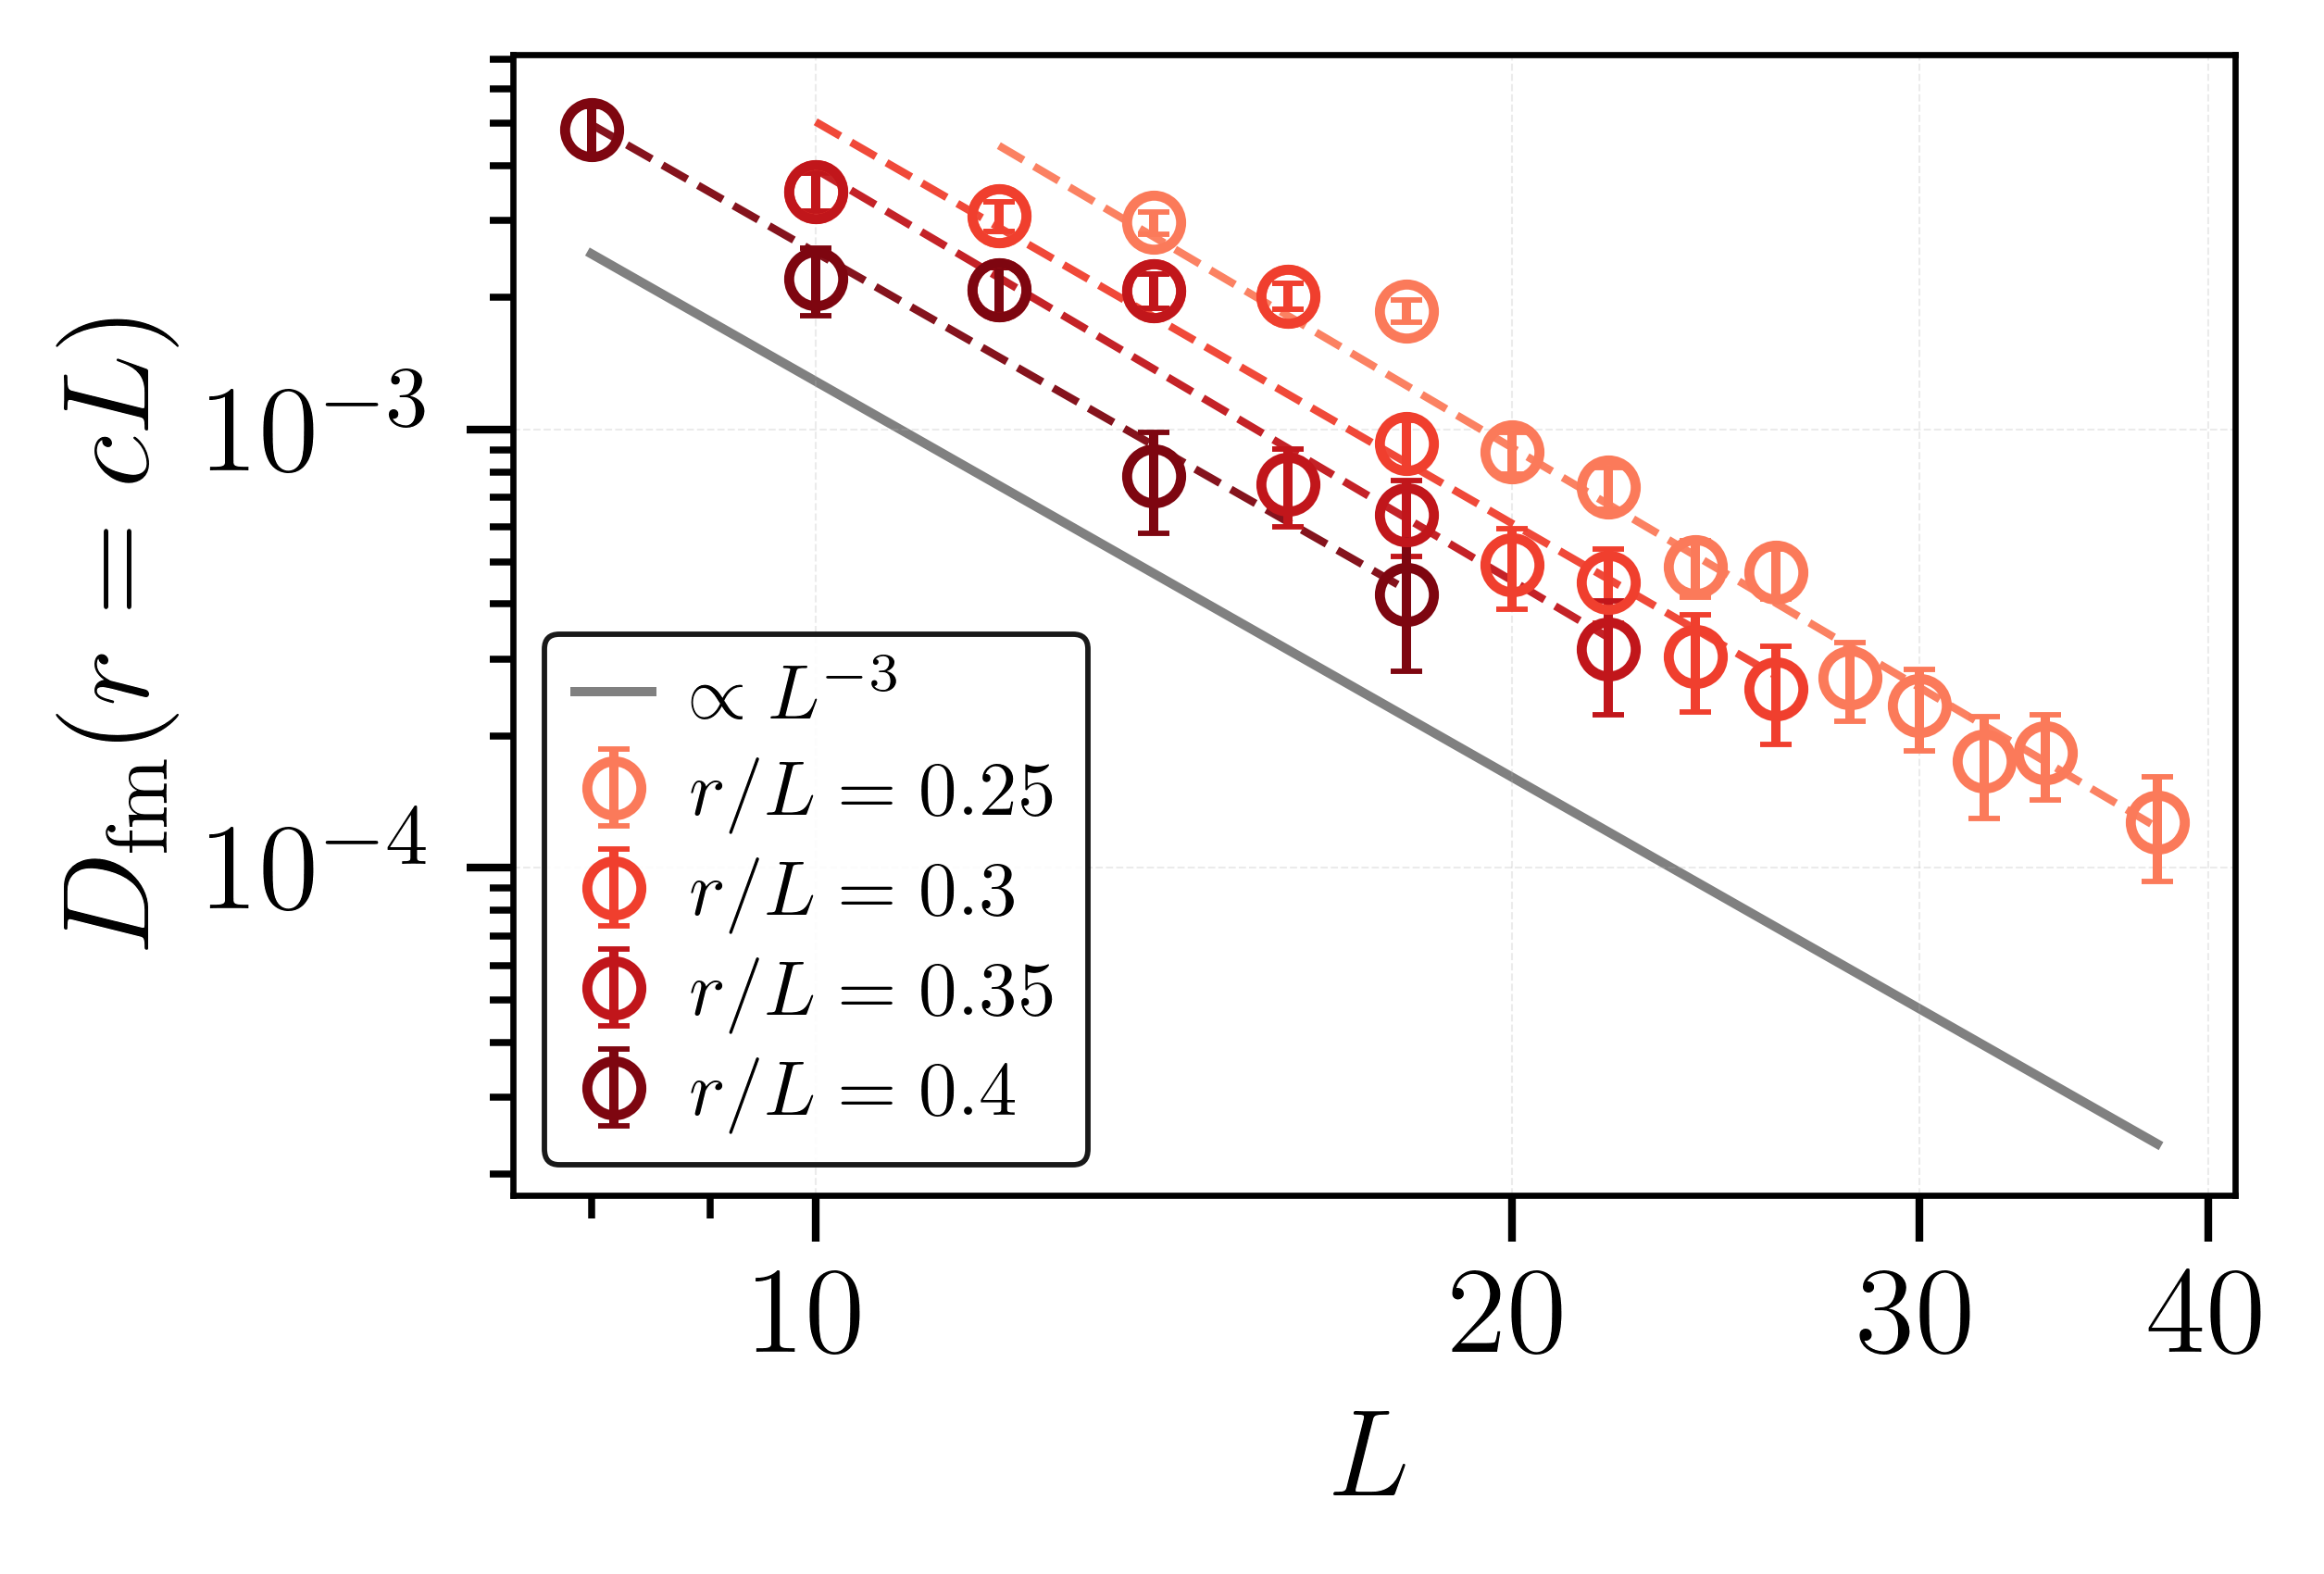

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, NullLocator
import matplotlib as mpl

LEGEND_FONTSIZE = 10

SNR_MIN = 3    # filter1: minimum SNR
R_MIN   = 3    # filter2: minimum absolute separation r

# -------------------- Matplotlib settings  --------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 16
TICK_FSIZE   = 16

REF_LINE_COLOR = 'gray'   # reference power-law line

# -------------------- L list --------------------
L_list  = [8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52]
L_ticks = [10, 20, 30, 40]

# -------------------- c = r/L values to plot --------------------
c_values = [0.25, 0.3, 0.35, 0.4]

# =====================
# Coloring
# =====================
CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Reds

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(values)
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * np.asarray(ts)
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

c_to_color = fixed_contrast_color_map(c_values)

# -------------------- figure -------
fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

all_valid_L    = []
all_valid_vals = []

# ======================== main loop over c =========================
for c in c_values:
    this_color = c_to_color[c]

    Ls_used = []
    vals    = []
    errs    = []

    for L in L_list:
        r = int(np.floor(c * L))
        idx = r - 1

        y     = globals()[f"C_DC_prod_osc_stag_{L}"]
        y_err = globals()[f"C_DC_prod_osc_stag_err_{L}"]

        if idx < 0 or idx >= len(y):
            continue

        yi = float(y[idx])
        ei = float(y_err[idx])
        if (not np.isfinite(yi)) or (not np.isfinite(ei)) or (yi <= 0.0) or (ei <= 0.0):
            continue

        Ls_used.append(L)
        vals.append(yi)
        errs.append(ei)

    if not vals:
        continue

    L_arr = np.array(Ls_used, dtype=float)
    vals  = np.array(vals, dtype=float)
    errs  = np.array(errs, dtype=float)

    rs_arr = np.array([int(np.floor(c * L)) for L in L_arr], dtype=float)

    snr = vals / errs
    mask = (snr >= SNR_MIN) & (rs_arr >= R_MIN)

    L_arr_f  = L_arr[mask]
    vals_f   = vals[mask]
    errs_f   = errs[mask]

    all_valid_L.extend(L_arr_f.tolist())
    all_valid_vals.extend(vals_f.tolist())

    if len(vals_f) < 2:
        print(
            f"c={c}: insufficient points after filters "
            f"(SNR ≥ {SNR_MIN}, r ≥ {R_MIN}); kept {len(vals_f)}."
        )
        continue

    eb = ax.errorbar(
        L_arr_f, vals_f,
        yerr=errs_f,
        fmt='o',
        color=this_color,
        markersize=7,
        markerfacecolor='none',
        capsize=2,
        elinewidth=1.2,
        capthick=0.7,
        label=rf'$r/L={c}$',
        zorder=3
    )
    eb[0].set_markeredgecolor(this_color)
    eb[0].set_markeredgewidth(1.3)

    # -------- log-log power-law fit --------
    xlog = np.log(L_arr_f)
    ylog = np.log(vals_f)
    m, b_lin = np.polyfit(xlog, ylog, 1)
    A = np.exp(b_lin)

    ylog_fit = m * xlog + b_lin
    ss_res = np.sum((ylog - ylog_fit)**2)
    ss_tot = np.sum((ylog - np.mean(ylog))**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    print(f"c = {c:.2f}: exponent m = {m:.4f}, R^2 = {R2:.4f}, N = {len(L_arr_f)}")

    L_fit = np.linspace(L_arr_f.min(), L_arr_f.max(), 300)
    ax.plot(
        L_fit, A * L_fit**m,
        '--', lw=1.0, color=this_color, alpha=0.95, zorder=2
    )

# -------------------- L^{-3} reference line --------------------
if len(all_valid_L) > 0:
    L_arr_all = np.array(all_valid_L, dtype=float)
    vals_all  = np.array(all_valid_vals, dtype=float)

    Lmin_valid = L_arr_all.min()
    Lmax_valid = L_arr_all.max()

    A_ref = np.min(vals_all * (L_arr_all**3)) * 0.6

    L_ref = np.linspace(Lmin_valid, Lmax_valid, 300)
    y_ref = A_ref * L_ref**(-3)

    ax.plot(
        L_ref, y_ref,
        color=REF_LINE_COLOR, lw=1.2, ls='-',
        label=r'$\propto L^{-3}$',
        zorder=1
    )

# -------------------- axes styling --------------------
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
ax.set_ylabel(r'${D}_{\text{fm}}(r=cL)$', fontsize=LABEL_FSIZE)

ax.set_xticks(L_ticks)
ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
# ax.xaxis.set_minor_locator(NullLocator())

ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

# -------------------- legend box --------------------
leg = ax.legend(
    fontsize=LEGEND_FONTSIZE,
    loc='lower left',
    handlelength=1,
    handletextpad=0.5,
    borderpad=0.4,
    labelspacing=0.3,
    borderaxespad=0.4,
    frameon=True,
)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(0.7)
frame.set_facecolor('white')
frame.set_alpha(0.9)

pdf_name = "Figs/various-r-L-2dMaj-fm.pdf"

plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,               
    bbox_inches="tight",   
    pad_inches=0.08,       
    transparent=False     
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()

# Fig.3(b)

Saved high-quality PDF as: Figs/2d-majorana-exp-decay.pdf


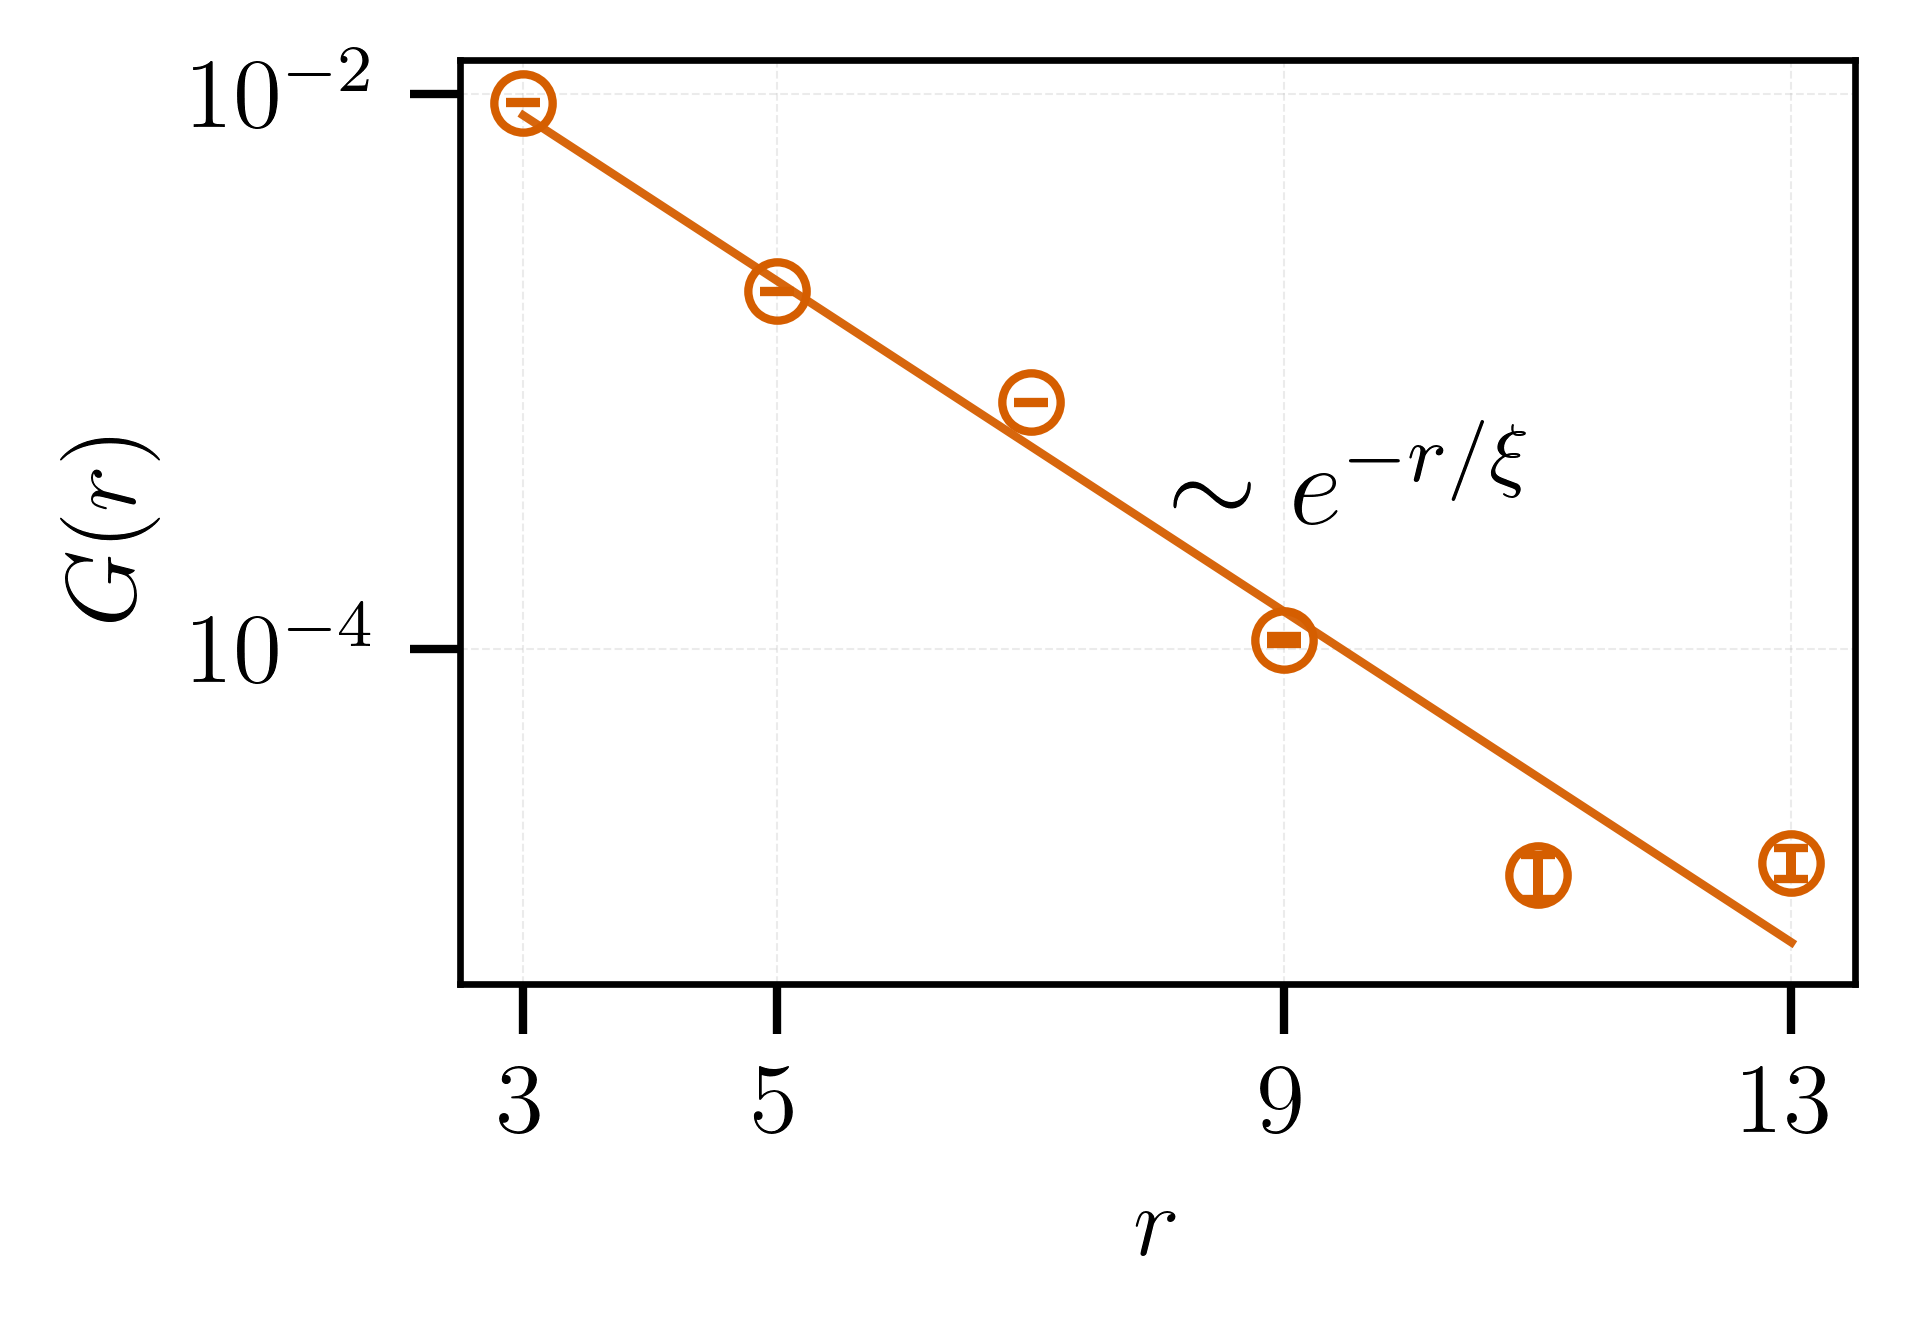

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import NullLocator, LogLocator, LogFormatterMathtext, FormatStrFormatter

# ---------------------------------------------------------
# Matplotlib / LaTeX settings  
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 12
TICK_FSIZE   = 12

# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------
L = 52
SNR_MIN = 3
r_min = 3
r_max = int(np.floor(L / 2))

# --------- x-axis tick control  ----------
X_TICKS = [3, 5, 9,  13]

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
G2_abs       = np.asarray(globals()[f"G2_Cx_abs_{L}"], dtype=float)
G2_abs_err   = np.asarray(globals()[f"G2_Cx_abs_err_{L}"], dtype=float)
G2           = np.asarray(globals()[f"G2_Cx_{L}"], dtype=float)
G2_err       = np.asarray(globals()[f"G2_Cx_err_{L}"], dtype=float)

# ---------------------------------------------------------
# r selection (odd r only)
# ---------------------------------------------------------
r_all = np.arange(1, len(G2_abs) + 1)
mask  = (r_all % 2 == 1) & (r_all >= r_min) & (r_all <= r_max)

r_odd       = r_all[mask]
G_signed    = G2[r_odd - 1]
G_signed_er = G2_err[r_odd - 1]

# ---------------------------------------------------------
# Compute SNR and apply filter
# ---------------------------------------------------------
SNR_signed = np.zeros_like(G_signed)
ok = (G_signed_er > 0) & np.isfinite(G_signed) & np.isfinite(G_signed_er)
SNR_signed[ok] = np.abs(G_signed[ok]) / G_signed_er[ok]

mask_signed_snr_ok = (SNR_signed >= SNR_MIN) & (np.abs(G_signed) > 0)

r_abs      = r_odd[mask_signed_snr_ok]
G_plot     = np.abs(G_signed[mask_signed_snr_ok])
G_plot_err = G_signed_er[mask_signed_snr_ok]

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 2), dpi=600)

col = '#D55E00'

# C_EA-style markers
eb = ax.errorbar(
    r_abs, G_plot, yerr=G_plot_err,
    fmt='o',
    markersize=7,
    markerfacecolor='none',
    markeredgewidth=1,
    capsize=2,
    elinewidth=1.2,
    capthick=0.7,
    color=col,
    zorder=3
)
eb[0].set_markeredgecolor(col)

# Exponential fit
log_y = np.log(G_plot)
b_e, a_e = np.polyfit(r_abs, log_y, 1)

r_line = np.linspace(r_abs.min(), r_abs.max(), 300)
ax.semilogy(
    r_line,
    np.exp(a_e + b_e * r_line),
    '-',
    lw=1.0,
    color=col,
    alpha=0.95,
    zorder=2
)

# ---------------------------------------------------------
# Labels + annotation
# ---------------------------------------------------------
ax.set_xlabel(r'$r$', fontsize=LABEL_FSIZE)
ax.set_ylabel(r'$G(r)$', fontsize=LABEL_FSIZE)
# ax.set_title(r'Random Majorana Lattice, $d=2$', fontsize=LABEL_FSIZE, pad=6)

ax.text(
    0.64, 0.53, r"$\sim e^{-r/\xi}$",
    fontsize=LABEL_FSIZE+2,
    ha="center", va="center",
    transform=ax.transAxes
)

# ---------------------------------------------------------
# Axis scales and ticks
# ---------------------------------------------------------
ax.set_yscale('log')

# y-axis (log with visible minor ticks)
ax.yaxis.set_major_locator(LogLocator(base=10.0))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

ax.minorticks_on()
ax.tick_params(axis='y', which='minor', left=True)

# x-axis (manual ticks)
ax.set_xticks(X_TICKS)
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.xaxis.set_minor_locator(NullLocator())

# tick styling
ax.tick_params(axis='both', which='major',
               labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor',
               length=4, width=0.9)

ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.25)
pdf_name = "Figs/2d-majorana-exp-decay.pdf"
plt.savefig(pdf_name, dpi=600, bbox_inches="tight", pad_inches=0.08)
print(f"Saved high-quality PDF as: {pdf_name}")
plt.show()

# Fig.4(b)

c = 0.25: exponent m = -4.6259, R^2 = 0.9824, N = 20
c = 0.30: exponent m = -4.8055, R^2 = 0.9845, N = 21
c = 0.40: exponent m = -5.1423, R^2 = 0.9908, N = 22
c = 0.50: exponent m = -5.3448, R^2 = 0.9978, N = 22
Saved high-quality PDF as: Figs/various-r-L-2dMaj-sc.pdf


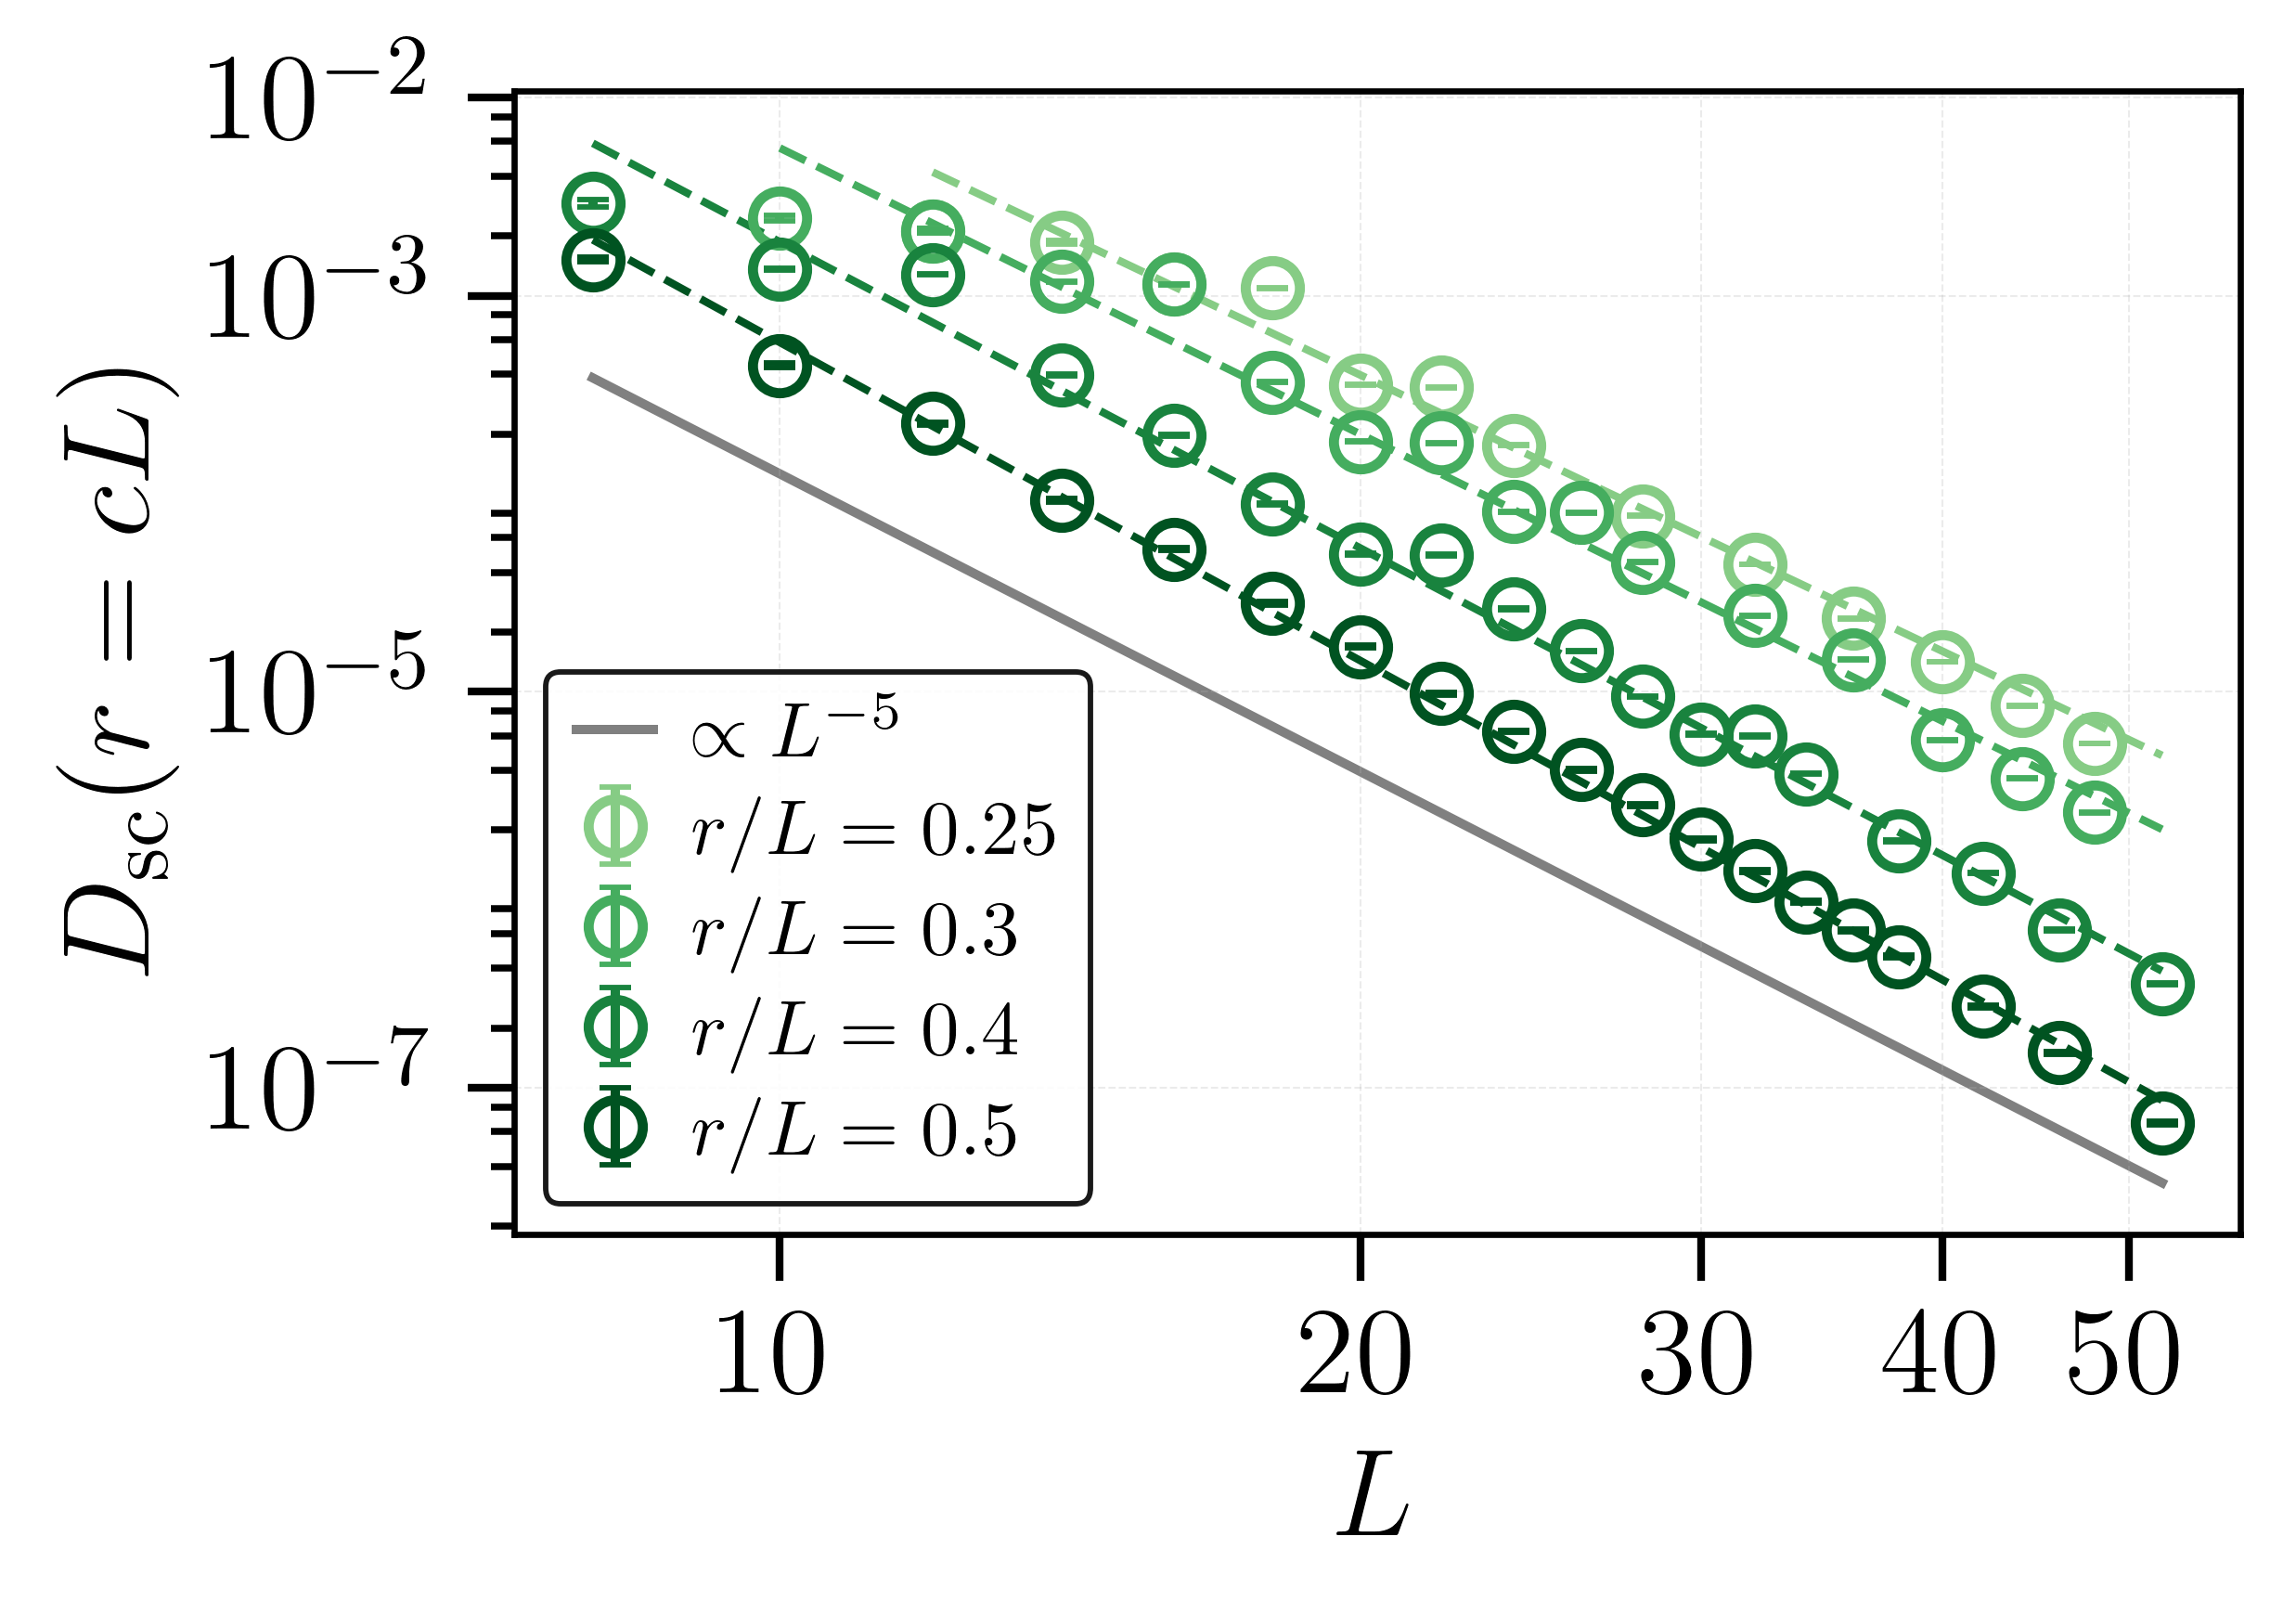

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import (
    FormatStrFormatter, NullLocator,
    LogLocator, LogFormatterMathtext, NullFormatter, FixedLocator
)
import matplotlib as mpl

LEGEND_FONTSIZE = 10

SNR_MIN = 3  
R_MIN   = 3     

# -------------------- subsampling rules --------------------
L_SAMPLE_RULES_BY_C = {
    0.25: [(22, 1), (52, 2)],
    0.30: [(26, 1), (52, 2)],
    0.40: [(32, 1), (52, 2)],
    0.50: [(36, 1), (52, 2)],
}
DEFAULT_L_SAMPLE_RULES = [(32, 1), (52, 2)]

def sample_by_L_rules(L, *arrays, rules):
    L = np.asarray(L, dtype=float)
    if L.size == 0:
        return (L,) + tuple(np.asarray(a) for a in arrays)

    order = np.argsort(L)
    Ls = L[order]
    arrs = [np.asarray(a)[order] for a in arrays]

    keep_global = np.zeros_like(Ls, dtype=bool)
    start = 0
    for Lmax, step in rules:
        end = np.searchsorted(Ls, Lmax, side='right')
        idx = np.arange(start, end)
        if idx.size > 0:
            keep_global[idx[::max(int(step), 1)]] = True
        start = end
        if start >= Ls.size:
            break

    Ls = Ls[keep_global]
    arrs = [a[keep_global] for a in arrs]
    return (Ls,) + tuple(arrs)

# -------------------- Matplotlib settings ---------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 16
TICK_FSIZE   = 16
REF_LINE_COLOR = 'gray'

# -------------------- L list --------------------
L_list = [8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52]
L_ticks = [10,20,30,40,50]

# -------------------- c = r/L values to plot --------------------
c_values = [0.25, 0.3, 0.4, 0.5]

# =============================
# Colormap control 
# =============================
CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Greens

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(values)
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * ts
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

c_to_color = fixed_contrast_color_map(c_values)

# ==========================================================
# Figure
# ==========================================================
fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

all_valid_L    = []
all_valid_vals = []

# ======================== main loop over c =========================
for c in c_values:

    Ls_used = []
    vals    = []
    errs    = []

    for L in L_list:

        r = int(np.floor(c * L))
        idx = r - 1

        y     = globals()[f"C_SC_osc_stag_{L}"]
        y_err = globals()[f"C_SC_osc_stag_err_{L}"]

        if idx < 0 or idx >= len(y):
            continue

        yi = float(y[idx])
        ei = float(y_err[idx])
        if (not np.isfinite(yi)) or (not np.isfinite(ei)) or (yi <= 0.0) or (ei <= 0.0):
            continue

        Ls_used.append(L)
        vals.append(yi)
        errs.append(ei)

    if not vals:
        continue

    L_arr  = np.array(Ls_used, dtype=float)
    vals   = np.array(vals, dtype=float)
    errs   = np.array(errs, dtype=float)

    rs_arr = np.array([int(np.floor(c * L)) for L in L_arr], dtype=float)

    snr = vals / errs
    mask = (snr >= SNR_MIN) & (rs_arr >= R_MIN)

    L_arr_f  = L_arr[mask]
    vals_f   = vals[mask]
    errs_f   = errs[mask]

    all_valid_L.extend(L_arr_f.tolist())
    all_valid_vals.extend(vals_f.tolist())

    if len(vals_f) < 2:
        print(
            f"c={c}: insufficient points after combined filters "
            f"(SNR ≥ {SNR_MIN}, r ≥ {R_MIN}); kept {len(vals_f)}."
        )
        continue

    # -------------------- PER-c subsampling --------------------
    rules_for_c = L_SAMPLE_RULES_BY_C.get(float(c), DEFAULT_L_SAMPLE_RULES)
    L_plot, vals_plot, errs_plot = sample_by_L_rules(L_arr_f, vals_f, errs_f, rules=rules_for_c)

    color = c_to_color[c]

    eb = ax.errorbar(
        L_plot, vals_plot,
        yerr=errs_plot,
        fmt='o',
        markersize=7,
        markerfacecolor='none',
        capsize=2,
        elinewidth=1.2,
        capthick=0.7,
        color=color,
        label=rf'$r/L={c}$',
        zorder=3
    )
    eb[0].set_markeredgecolor(color)
    eb[0].set_markeredgewidth(1.3)

    # -------- power-law fit  --------
    xlog = np.log(L_arr_f)
    ylog = np.log(vals_f)
    m, b_lin = np.polyfit(xlog, ylog, 1)
    A = np.exp(b_lin)

    ylog_fit = m * xlog + b_lin
    ss_res = np.sum((ylog - ylog_fit)**2)
    ss_tot = np.sum((ylog - np.mean(ylog))**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    print(f"c = {c:.2f}: exponent m = {m:.4f}, R^2 = {R2:.4f}, N = {len(L_arr_f)}")

    L_fit = np.linspace(min(L_arr_f), max(L_arr_f), 200)
    ax.plot(L_fit, A * L_fit**m, '--', lw=1, color=color, alpha=1, zorder=2)

# -------------------- L^{-5} reference line --------------------
if len(all_valid_L) > 0:
    L_arr_all = np.array(all_valid_L, dtype=float)
    vals_all  = np.array(all_valid_vals, dtype=float)

    Lmin_valid = L_arr_all.min()
    Lmax_valid = L_arr_all.max()

    A_ref = np.min(vals_all * (L_arr_all**5)) * 0.5
    L_ref = np.linspace(Lmin_valid, Lmax_valid, 200)
    y_ref = A_ref * L_ref**(-5)

    ax.plot(
        L_ref, y_ref,
        color=REF_LINE_COLOR, lw=1.2, ls='-',
        label=r'$\propto L^{-5}$',
        zorder=1
    )

# -------------------- main axes --------------------
ax.set_xscale('log')
ax.set_yscale('log')

major_yticks = [1e-2, 1e-3, 1e-5, 1e-7]
ax.yaxis.set_major_locator(FixedLocator(major_yticks))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))

ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=100))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis='y', which='minor', left=True, right=False)

ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
ax.set_ylabel(r'${D}_{\text{sc}}(r=cL)$', fontsize=LABEL_FSIZE)

ax.set_xticks(L_ticks)
ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
ax.xaxis.set_minor_locator(NullLocator())

ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

leg = ax.legend(
    fontsize=LEGEND_FONTSIZE,
    loc='lower left',
    handlelength=1,
    handletextpad=0.5,
    borderpad=0.4,
    labelspacing=0.3,
    borderaxespad=0.4,
    frameon=True
)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(0.7)
frame.set_facecolor('white')
frame.set_alpha(0.9)


pdf_name = "Figs/various-r-L-2dMaj-sc.pdf"

plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,               # high resolution for any rasterized bits
    bbox_inches="tight",   # avoid cropping labels
    pad_inches=0.08,       # small padding
    transparent=False      # keep clean white background
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()